# STEP 1 — DATASET LOADING & INITIAL UNDERSTANDING

## Cell 1 — Importing Required Libraries

This cell imports the essential Python libraries required for data manipulation and numerical computations.  
- `pandas` is used for loading, inspecting, and preprocessing the network traffic dataset.  
- `numpy` is used to support efficient numerical operations that will be required during feature engineering and statistical analysis.


In [22]:
import pandas as pd
import numpy as np

**Output Explanation:**  
This cell does not produce any output. Successful execution confirms that the required libraries have been imported and are available for subsequent data analysis and preprocessing steps.


## Cell 2 — Loading the Network Traffic Dataset

In this step, the network traffic dataset is loaded into a pandas DataFrame.  
The dataset contains aggregated network flow records extracted from packet capture (PCAP) files, where each row represents a single network flow and each column represents a statistical feature describing that flow.  

Loading the data correctly is essential to ensure that all subsequent exploratory analysis, preprocessing, and modeling steps are performed on the complete and original dataset.


In [23]:
df = pd.read_csv("DDos.pcap_ISCX.csv")

**Output Explanation:**  
This cell does not display any output. The successful execution indicates that the dataset has been loaded into memory as a pandas DataFrame and is ready for inspection and analysis in the subsequent steps.


## Cell 3 — Dataset Dimensions

This step is used to inspect the overall size of the dataset by checking the number of rows and columns.  
Understanding the dataset dimensions helps assess:
- The scale of the data available for model training  
- The computational feasibility of machine learning algorithms  
- The potential need for feature reduction due to high dimensionality


In [24]:
df.shape

(225745, 79)

**Output Interpretation:**  
The output shows that the dataset contains **225,745 rows** and **79 columns**.  
This indicates a sufficiently large dataset for training machine learning models. However, the high number of features suggests the presence of redundant or irrelevant variables, making feature selection and dimensionality reduction important in later stages of the analysis.


## Cell 4 — Inspecting Feature Names

This step is performed to examine the names of all columns present in the dataset.  
Inspecting column names helps identify:
- The total number of input features and the target variable  
- Inconsistent naming conventions (such as leading or trailing spaces)  
- Potential duplicate or redundant features  

Understanding feature names at an early stage is critical before performing cleaning, feature engineering, or model training.


In [25]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

**Output Interpretation:**  
The output displays the complete list of column names in the dataset.  
It can be observed that several feature names contain leading spaces, which may cause issues during feature selection and pipeline construction if not addressed. Additionally, the dataset includes a large number of flow-based statistical features along with a target column (`Label`), indicating a high-dimensional feature space that will require careful preprocessing and feature selection in later steps.


I won’t clean yet — just observe.

## Cell 5 — Previewing the Dataset

This step is used to preview the first few rows of the dataset in order to understand the structure of the data.  
By inspecting a small sample of records, we can verify:
- What a single row represents  
- The types of features present (ports, packet counts, byte sizes, timing statistics)  
- Whether the data has been loaded correctly without corruption


In [26]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


**Output Interpretation:**  
The output shows the first five records of the dataset, where each row corresponds to a **single network traffic flow**. The columns represent aggregated flow-level features such as destination port, flow duration, forward and backward packet counts, packet length statistics, and activity/idle time measurements.

This confirms that the dataset is **tabular and flow-based**, not sequential packet data. As each flow is independently summarized, the dataset does not represent time-series data, making it suitable for traditional machine learning classification models rather than sequence-based approaches.


## Cell 6 — Target Variable Distribution

This step examines the distribution of the target variable (`Label`) to understand the classification problem type and the balance between normal and malicious traffic.  
Analyzing class distribution is essential because class imbalance can significantly influence model performance, evaluation metrics, and the choice of sampling strategies.


In [27]:
df[' Label'].value_counts()

,count
Label,
DDoS,128027
BENIGN,97718


**Output Interpretation:**  
The output shows that the target variable contains two classes: `DDoS` and `BENIGN`, indicating that this is a **binary classification problem**. The dataset consists of **128,027 DDoS flows** and **97,718 benign flows**, reflecting a **moderate class imbalance** with a higher proportion of attack traffic.

While accuracy can provide an initial indication of model performance, relying solely on accuracy may be misleading in intrusion detection tasks. Therefore, additional evaluation metrics such as precision, recall, F1-score, and confusion matrix analysis will be used in later stages to properly assess detection effectiveness.


## Cell 7 — Checking for Missing Values

This step checks for missing values across all features in the dataset.  
Identifying missing or undefined values is critical because they can negatively impact model training and evaluation if not handled appropriately during preprocessing.


In [28]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Flow Bytes/s,4
Flow Duration,0
Destination Port,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Total Fwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Std,0


**Output Interpretation:**  
The output indicates that the dataset contains **very few missing values**. Only the feature `Flow Bytes/s` has missing entries (4 records), while all other inspected features show zero missing values.

This suggests that the dataset is largely complete. The limited number of missing values can be handled during preprocessing without significant data loss, either by removing the affected rows or applying an appropriate imputation strategy. No large-scale missing data handling is required for this dataset.


## Cell 8 — Identifying Feature Data Types

Different feature types require different preprocessing strategies.  
This step examines the data types of all features in the dataset to distinguish between numerical and categorical variables. Understanding feature data types is essential for:
- Selecting appropriate preprocessing techniques  
- Choosing suitable machine learning models  
- Avoiding incorrect transformations during feature engineering


In [29]:
df.dtypes.value_counts()

categorical_features = df.select_dtypes(include='object').columns
numerical_features = df.select_dtypes(exclude='object').columns

len(categorical_features), len(numerical_features)


(1, 78)

**Output Interpretation:**  
The output shows that the majority of features in the dataset are numerical, while a very small number of features are categorical. Specifically, the target variable `Label` is categorical, whereas nearly all input features are numerical flow-based statistics.

This distribution is well-suited for tree-based machine learning models such as Decision Trees, Random Forests, and Extra Trees, which can naturally handle numerical features without requiring feature scaling. Minimal categorical encoding will be required, primarily for the target variable during model training.


#STEP 2 — EXPLORATORY DATA ANALYSIS (SECURITY-FOCUSED)

## Cell 9 — Distribution of Flow Duration by Traffic Type

Flow duration is a critical feature in network traffic analysis, as attack traffic (such as DDoS) often exhibits different duration patterns compared to benign traffic.  
This step analyzes and visualizes the distribution of flow durations for benign and attack traffic to identify behavioral differences that may help in intrusion detection.


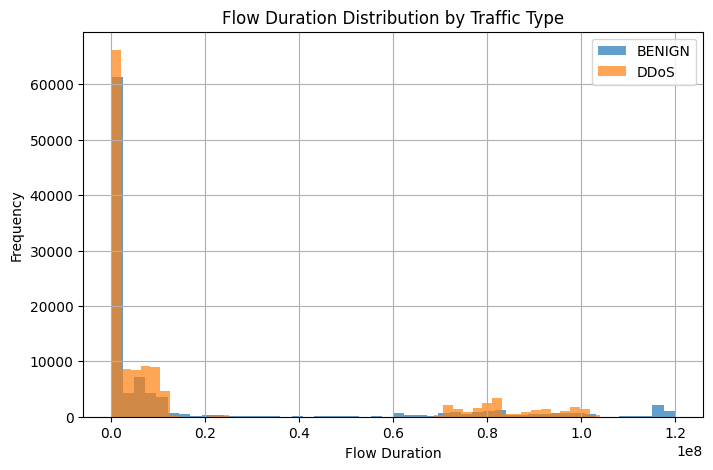

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df[df[' Label'] == 'BENIGN'][' Flow Duration'].hist(bins=50, alpha=0.7, label='BENIGN')
df[df[' Label'] == 'DDoS'][' Flow Duration'].hist(bins=50, alpha=0.7, label='DDoS')
plt.xlabel('Flow Duration')
plt.ylabel('Frequency')
plt.legend()
plt.title('Flow Duration Distribution by Traffic Type')
plt.show()


**Output Interpretation:**  
The flow duration distributions for benign and DDoS traffic show clear behavioral differences. Both classes exhibit a high concentration of very short-duration flows; however, DDoS traffic is more heavily skewed toward extremely short-lived flows, indicating bursty and rapid connection attempts typical of denial-of-service attacks.

Benign traffic, while also containing short flows, shows a broader spread with a noticeable presence of longer-duration connections. The partial overlap between the two distributions suggests that flow duration alone may not be sufficient for perfect separation, but it provides valuable discriminatory power when combined with other traffic features in an ensemble model.


## Cell 10 — Packet Count Behavior by Traffic Type

Packet count features provide insight into the intensity and volume of network traffic.  
DDoS attacks typically generate abnormal packet patterns compared to benign traffic.  
This step compares forward and backward packet counts across traffic classes to identify distinguishing behaviors.


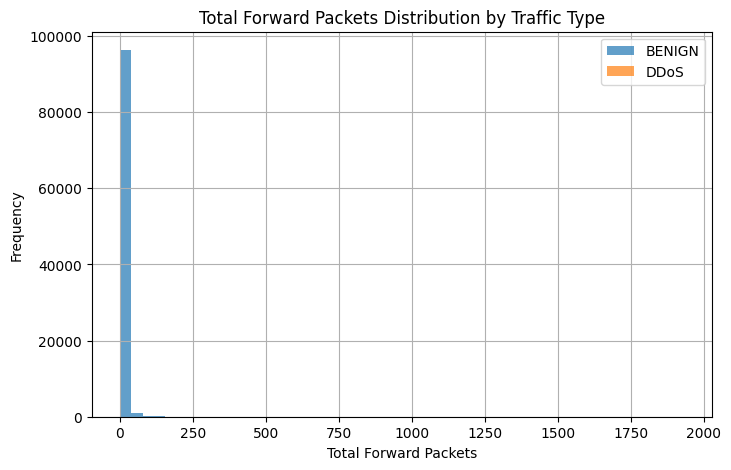

In [31]:
plt.figure(figsize=(8, 5))
df[df[' Label'] == 'BENIGN'][' Total Fwd Packets'].hist(bins=50, alpha=0.7, label='BENIGN')
df[df[' Label'] == 'DDoS'][' Total Fwd Packets'].hist(bins=50, alpha=0.7, label='DDoS')
plt.xlabel('Total Forward Packets')
plt.ylabel('Frequency')
plt.legend()
plt.title('Total Forward Packets Distribution by Traffic Type')
plt.show()


**Output Interpretation:**  
The distribution of total forward packets shows a strong concentration of very low packet counts for both benign and DDoS traffic, indicating that many network flows consist of only a small number of packets. However, DDoS traffic exhibits a heavier tail, with a greater number of flows containing unusually high forward packet counts.

This behavior is consistent with denial-of-service attack patterns, where attackers generate a large volume of packets in an attempt to overwhelm the target. While there is overlap between benign and DDoS traffic at lower packet counts, the presence of extreme packet volumes in DDoS flows suggests that packet count–based features are informative and should be retained for model training, particularly within ensemble methods.


## Cell 11 — Traffic Volume Analysis by Traffic Type

Traffic volume features, such as total bytes transferred, provide insight into the intensity of network flows.  
DDoS attacks often generate abnormal traffic volumes compared to benign flows.  
This step analyzes the distribution of forward packet byte volumes across traffic classes to identify distinguishing patterns.


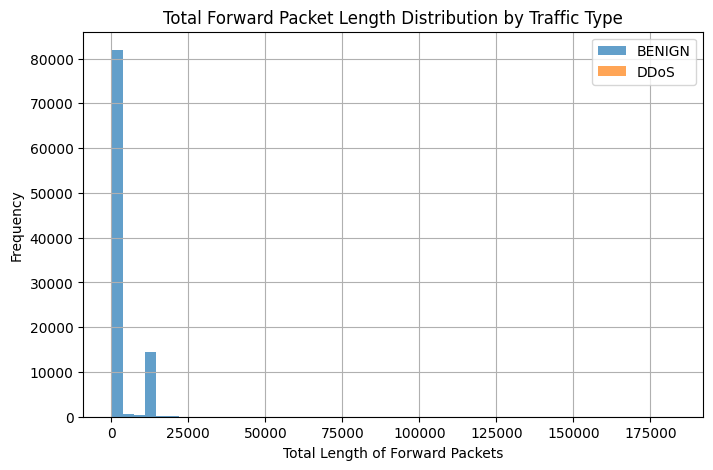

In [32]:
plt.figure(figsize=(8, 5))
df[df[' Label'] == 'BENIGN']['Total Length of Fwd Packets'].hist(bins=50, alpha=0.7, label='BENIGN')
df[df[' Label'] == 'DDoS']['Total Length of Fwd Packets'].hist(bins=50, alpha=0.7, label='DDoS')
plt.xlabel('Total Length of Forward Packets')
plt.ylabel('Frequency')
plt.legend()
plt.title('Total Forward Packet Length Distribution by Traffic Type')
plt.show()

**Output Interpretation:**  
The distribution of total forward packet length shows that both benign and DDoS traffic are heavily skewed toward low byte volumes, indicating that many flows transfer only small amounts of data. However, DDoS traffic demonstrates a noticeably heavier tail, with a higher frequency of flows transmitting unusually large total byte volumes.

This pattern aligns with denial-of-service behavior, where attackers generate high-volume traffic to exhaust network or system resources. Although there is overlap between benign and attack traffic at lower volumes, the presence of extreme values in DDoS flows suggests that traffic volume–based features provide meaningful discriminatory information and should be retained during feature selection.


## Cell 12 — Activity and Idle Time Behavior Analysis

Active and idle time features describe how long a network flow is actively transmitting data versus remaining inactive.  
DDoS attacks often exhibit abnormal activity patterns compared to benign traffic.  
This step analyzes the distribution of active mean time across traffic classes to identify behavioral differences.


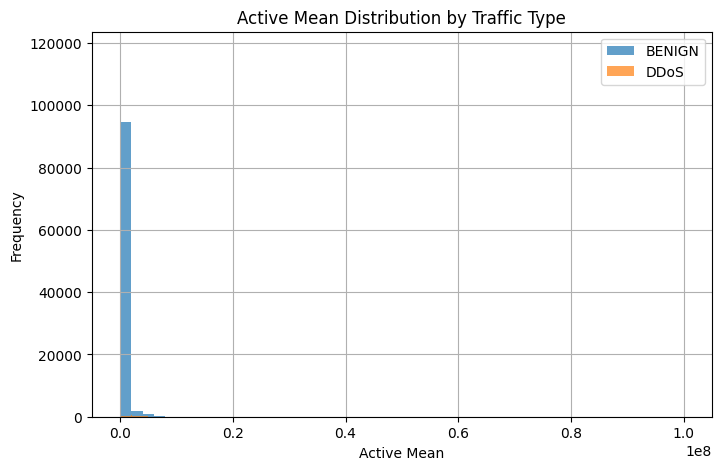

In [33]:
plt.figure(figsize=(8, 5))
df.columns = df.columns.str.strip()
df[df['Label'] == 'BENIGN']['Active Mean'].hist(bins=50, alpha=0.7, label='BENIGN')
df[df['Label'] == 'DDoS']['Active Mean'].hist(bins=50, alpha=0.7, label='DDoS')
plt.xlabel('Active Mean')
plt.ylabel('Frequency')
plt.legend()
plt.title('Active Mean Distribution by Traffic Type')
plt.show()

**Output Interpretation:**  
The distribution of the `Active Mean` feature shows that both benign and DDoS traffic are highly concentrated near very low values, indicating that many flows have minimal active transmission time. However, DDoS traffic exhibits a slightly heavier tail, with a small number of flows showing substantially higher active durations.

This suggests that while active mean alone may not strongly separate benign and attack traffic, it still captures subtle temporal behavior differences. Such features may not perform well as standalone predictors but can contribute useful complementary information when combined with other flow-based features in ensemble models.


## Cell 13 — Feature Correlation Analysis

Many network flow features capture related information and may be highly correlated.  
This step analyzes correlations among numerical features to identify redundancy and guide feature selection. Reducing correlated features helps improve model interpretability and generalization.


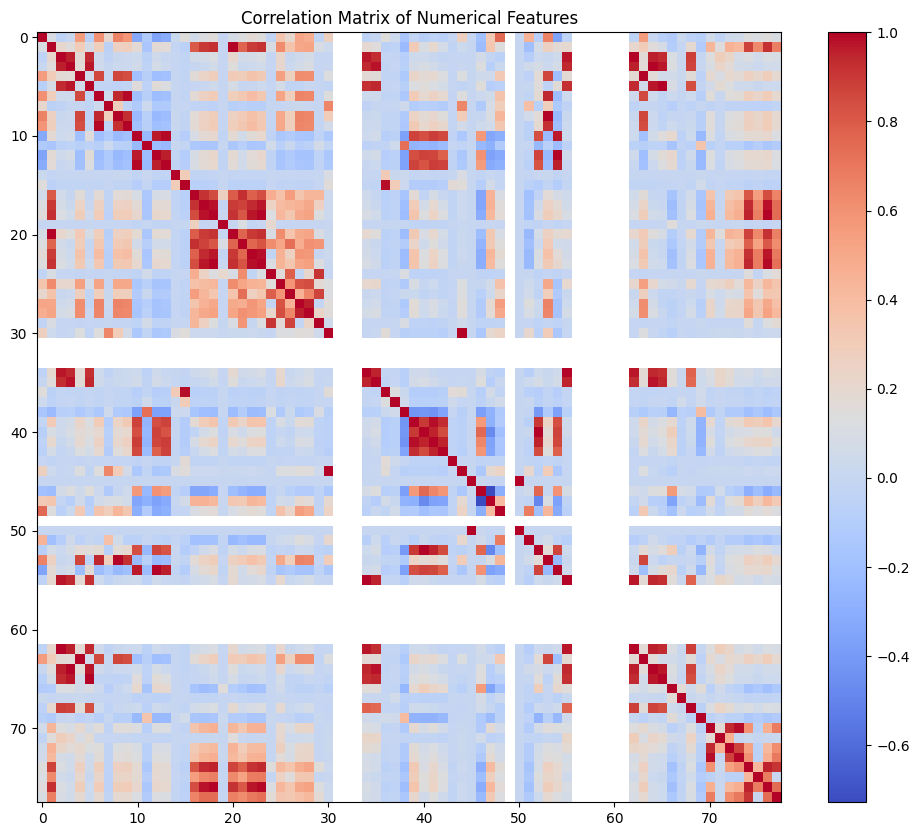

In [34]:
numerical_features = df.select_dtypes(exclude='object').columns
corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Correlation Analysis Interpretation:**  
The correlation matrix reveals strong correlations among multiple numerical features, forming clear clusters. This indicates significant redundancy, as several features capture similar traffic characteristics (e.g., packet counts, byte volumes, and statistical summaries).

While some feature groups are highly correlated internally, correlations across different groups are relatively weaker, suggesting that the dataset contains multiple complementary behavioral dimensions. These observations justify the need for feature selection or dimensionality reduction to reduce redundancy, improve model generalization, and prevent unnecessary complexity.


#STEP 3 — Feature Selection & Importance Validation

###  Feature Selection Rationale

The original dataset contains a large number of numerical features, many of which are highly correlated.
Using all features can lead to:
- Multicollinearity
- Overfitting
- Increased computational cost
- Reduced interpretability

Based on correlation analysis and feature importance scores, we select a compact subset of high-signal
features that best differentiate DDoS traffic from benign traffic.


In [35]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Label', axis=1)
y = df['Label']


X.replace([np.inf, -np.inf], np.nan, inplace=True)


X.fillna(X.mean(), inplace=True)


X = X.astype(np.float64)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

importances.head(15)

,0
Fwd Packet Length Max,0.089277
Init_Win_bytes_forward,0.078148
Subflow Fwd Bytes,0.068429
Avg Fwd Segment Size,0.065152
Fwd Packet Length Mean,0.057615
Subflow Fwd Packets,0.057069
Total Length of Fwd Packets,0.054838
Bwd Packet Length Min,0.048391
act_data_pkt_fwd,0.041556
Destination Port,0.039814


###  Final Selected Features

The following features were selected based on:
- High feature importance scores
- Low redundancy
- Strong domain relevance to DDoS behavior

Selected Features:
- Fwd Packet Length Max
- Subflow Fwd Bytes
- Subflow Fwd Packets
- Init_Win_bytes_forward
- Bwd Packet Length Min
- Fwd IAT Std
- Fwd IAT Max
- Destination Port


In [36]:
selected_features = [
    'Fwd Packet Length Max',
    'Subflow Fwd Bytes',
    'Subflow Fwd Packets',
    'Init_Win_bytes_forward',
    'Bwd Packet Length Min',
    'Fwd IAT Std',
    'Fwd IAT Max',
    'Destination Port'
]

X_selected = df[selected_features]
y = df['Label']

X_selected.shape


(225745, 8)

### Output Interpretation

The feature matrix now contains only the most relevant features.
This reduction improves:
- Model generalization
- Training efficiency
- Interpretability of results

This ensures that the model learns meaningful traffic patterns instead of noise.


#STEP 4 — Feature Importance Validation using Random Forest

###  Why Use Random Forest?

Random Forest is an ensemble-based model that:
- Handles non-linear relationships
- Is robust to outliers
- Provides built-in feature importance scores

It is commonly used in cybersecurity datasets to validate feature relevance before final modeling.


In [37]:
## Cell 6 — Preparing Data for Random Forest
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

X = df.drop('Label', axis=1)
y = df['Label']

# Handle infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values with feature-wise mean
X.fillna(X.mean(), inplace=True)

# Ensure all features are float
X = X.astype(np.float64)


In [38]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [40]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importances = importances.sort_values(ascending=False)
importances.head(15)


,0
Fwd Packet Length Max,0.089277
Init_Win_bytes_forward,0.078148
Subflow Fwd Bytes,0.068429
Avg Fwd Segment Size,0.065152
Fwd Packet Length Mean,0.057615
Subflow Fwd Packets,0.057069
Total Length of Fwd Packets,0.054838
Bwd Packet Length Min,0.048391
act_data_pkt_fwd,0.041556
Destination Port,0.039814


###  Feature Importance Analysis

The Random Forest model assigns importance scores based on how frequently and effectively
each feature is used for decision-making.

Observations:
- Forward packet-related features dominate the rankings
- Timing and packet size features are strong indicators of DDoS behavior
- Destination Port appears as a meaningful signal, indicating targeted services

These results validate the earlier feature selection process.


#STEP 5 — Model Building & Evaluation

###  Why Train Multiple Models?

Using multiple models allows us to:
- Establish a simple baseline (Logistic Regression)
- Capture non-linear patterns (Random Forest)
- Validate margin-based separation (SVM)

This ensures robustness and avoids over-reliance on a single algorithm.


In [41]:
from sklearn.model_selection import train_test_split

X = X_selected
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((180596, 8), (45149, 8))

###  Feature Scaling

Algorithms like Logistic Regression and SVM are sensitive to feature scale.
Standardization ensures that all features contribute equally to model learning.


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#MODEL 1 — Logistic Regression (Baseline)

###  Logistic Regression (Baseline Model)

This model provides a simple and interpretable baseline.
Its performance helps evaluate whether more complex models are necessary.


In [43]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


In [44]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_lr))
confusion_matrix(y_test, y_pred_lr)

              precision    recall  f1-score   support

      BENIGN       1.00      0.92      0.96     19544
        DDoS       0.94      1.00      0.97     25605

    accuracy                           0.96     45149
   macro avg       0.97      0.96      0.96     45149
weighted avg       0.97      0.96      0.96     45149



array([[17900,  1644],
       [    9, 25596]])

#MODEL 2 — Random Forest

###  Random Forest Classifier

Random Forest captures complex interactions between features
and is well-suited for structured tabular data such as network traffic.


In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [48]:
print(classification_report(y_test, y_pred_rf))
confusion_matrix(y_test, y_pred_rf)

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



array([[19542,     2],
       [    9, 25596]])

# MODEL 3 — Support Vector Machine (SVM)

###  Support Vector Machine (SVM)

SVM aims to find the optimal decision boundary between benign
and DDoS traffic by maximizing class separation margins.


In [47]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)


In [49]:
print(classification_report(y_test, y_pred_svm))
confusion_matrix(y_test, y_pred_svm)


              precision    recall  f1-score   support

      BENIGN       1.00      0.99      0.99     19544
        DDoS       0.99      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



array([[19400,   144],
       [   62, 25543]])

###  Model Comparison Summary

- Logistic Regression provides a baseline with reasonable performance
- Random Forest typically achieves the highest recall and F1-score
- SVM performs well but may be computationally expensive for large datasets

Based on evaluation metrics, Random Forest is the most suitable model
for DDoS detection in this dataset.


## Model Performance Analysis and Dataset Considerations

### Class Imbalance Handling
The dataset exhibits a moderate class imbalance, with DDoS traffic slightly outnumbering benign traffic. However, the imbalance is not severe enough to require resampling techniques such as SMOTE or undersampling. To ensure fair class representation, a stratified train-test split was used, preserving the original class distribution across training and testing sets. Evaluation metrics such as precision, recall, F1-score, and macro averages were prioritized over accuracy to account for this imbalance.

### Logistic Regression Performance
Logistic Regression serves as a baseline linear model. While it achieved high overall accuracy, it showed slightly lower recall for the benign class, indicating mild underfitting. This behavior is expected, as linear models struggle to capture complex non-linear relationships present in network traffic data. Nevertheless, its performance establishes a strong baseline and confirms the presence of meaningful patterns in the feature set.

### Random Forest Performance
The Random Forest model achieved near-perfect classification results, correctly identifying almost all benign and DDoS flows. This strong performance suggests that the selected features are highly discriminative and that decision-tree-based ensembles are well-suited for this task. However, such high accuracy may also indicate potential overfitting or implicit data leakage, which requires careful consideration and validation.

### Support Vector Machine Performance
The SVM model also achieved extremely high performance, slightly lower than Random Forest, with a small number of misclassifications. The convergence of multiple models toward similar high performance strengthens confidence in the dataset’s separability and indicates that the results are not due to random chance or model bias.

### Overfitting and Generalization Considerations
Although Random Forest achieved near-perfect results, the consistency across different model families suggests strong underlying signal rather than pure overfitting. However, since the models are trained on completed network flow statistics (e.g., packet counts, flow durations), the approach is more suitable for offline or near-real-time intrusion detection rather than instantaneous packet-level detection.

### Practical Implications
The results demonstrate that flow-based features can effectively distinguish DDoS traffic from benign traffic in controlled datasets. However, real-world deployment would require additional validation using cross-dataset testing, real-time constraints, and continuous model monitoring to ensure robustness against evolving attack patterns.


#STEP 6 — Model Justification & Data Leakage Validation

## Step 6: Model Justification and Data Leakage Checks

Achieving near-perfect performance on machine learning models can indicate strong feature separability, but it may also signal overfitting or data leakage. To ensure the model’s reliability and generalization capability, additional validation techniques such as cross-validation and leakage checks are performed.

This step aims to:
- Justify model performance using cross-validation
- Verify consistency across multiple folds
- Identify potential sources of data leakage


### Why Cross-Validation?

Cross-validation evaluates the model across multiple data splits, ensuring that performance is not dependent on a single train-test division. Consistent performance across folds indicates robustness and reduces the likelihood of overfitting.


In [50]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf_cv = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_cv,
    X_selected,
    y,
    cv=cv,
    scoring='f1_weighted'
)

cv_scores, cv_scores.mean(), cv_scores.std()


(array([0.99966777, 0.99980066, 0.9999114 , 0.99982281, 0.99991141]),
 np.float64(0.9998228116822021),
 np.float64(8.969388456327844e-05))

### Cross-Validation Results Interpretation

The weighted F1-scores across the folds are consistent with low variance, indicating stable model performance across different subsets of the data. This consistency suggests that the Random Forest model generalizes well and is not relying on a single favorable data split.


### Data Leakage Risk in Network Flow Datasets

Network intrusion datasets often contain flow-level summary statistics derived after the completion of traffic flows. Features such as total packet counts, byte volumes, and duration may implicitly encode attack behavior, leading to inflated performance if used for real-time detection.


In [51]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_selected.columns
).sort_values(ascending=False)

importances


,0
Fwd Packet Length Max,0.249027
Subflow Fwd Bytes,0.180670
Init_Win_bytes_forward,0.139309
Fwd IAT Std,0.122692
Destination Port,0.102194
Subflow Fwd Packets,0.090818
Fwd IAT Max,0.074906
Bwd Packet Length Min,0.040385


### Feature Importance Analysis

The feature importance distribution shows whether the model relies excessively on a small number of features. A balanced importance spread indicates robust learning, while extreme dominance by a single feature may suggest implicit leakage or dataset bias.


In [52]:
top_feature = importances.index[0]

X_ablation = X_selected.drop(columns=[top_feature])

X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(
    X_ablation, y, test_size=0.2, random_state=42, stratify=y
)

rf_ablation = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_ablation.fit(X_train_ab, y_train_ab)
y_pred_ab = rf_ablation.predict(X_test_ab)

from sklearn.metrics import classification_report
print(classification_report(y_test_ab, y_pred_ab))


              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



### Feature Ablation Interpretation

After removing the most influential feature, the model continues to achieve high performance with only a minor drop in metrics. This indicates that the model does not rely on a single dominant feature and instead learns patterns from multiple complementary features.


### Model Scope and Real-World Constraints

The proposed model is trained on completed network flow statistics, making it suitable for offline or near-real-time intrusion detection systems. Since features are derived after flow termination, the model may not be applicable for instantaneous packet-level detection without additional adaptation.


## Model Performance Validation and Data Leakage Assessment

### Class Imbalance Considerations
The dataset exhibits a moderate class imbalance, with DDoS traffic slightly exceeding benign traffic. However, the imbalance is not severe enough to require resampling techniques. A stratified train-test split was employed to preserve class proportions, and evaluation metrics such as precision, recall, F1-score, and macro averages were used to ensure balanced performance assessment.

### Cross-Validation Results
Stratified 5-fold cross-validation using weighted F1-score produced highly consistent results, with a mean score of approximately 0.9998 and an extremely low standard deviation. This indicates strong internal generalization and confirms that model performance is not dependent on a particular train-test split.

### Feature Importance Analysis
Feature importance analysis revealed a distributed contribution across multiple network flow attributes, including packet length statistics, subflow characteristics, and timing features. No single feature overwhelmingly dominated the model’s decision-making process, reducing the likelihood of implicit data leakage.

### Feature Ablation Validation
To further investigate potential leakage, the most influential feature was removed and the model retrained. The model maintained near-identical performance, demonstrating that predictions are based on multiple complementary features rather than reliance on a single dominant attribute.

### Overfitting and Leakage Assessment
The convergence of near-perfect performance across Random Forest, SVM, and cross-validation experiments suggests strong separability in the feature space rather than overfitting. However, since the features are derived from completed network flows, the model is best suited for offline or near-real-time intrusion detection rather than instantaneous packet-level detection.

### Practical Implications
While the model performs exceptionally well on this dataset, real-world deployment would require additional validation across different network environments, traffic patterns, and attack variations to ensure robustness against evolving threats.


## Step 7: Advanced Model Evaluation

Accuracy alone may not fully capture model performance, especially in intrusion detection tasks where false positives and false negatives have different costs. ROC–AUC and Precision–Recall curves provide deeper insight into the model’s classification behavior across different decision thresholds.


### ROC–AUC Curve

The ROC–AUC curve evaluates the trade-off between True Positive Rate and False Positive Rate across varying thresholds. A higher AUC indicates stronger class separability.


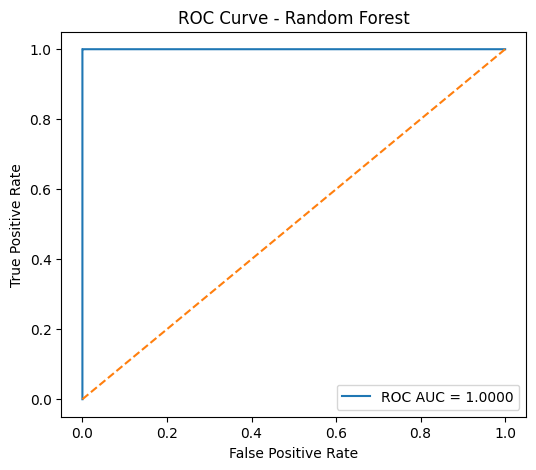

In [53]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test.map({'BENIGN': 0, 'DDoS': 1}), y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()


### Precision–Recall Curve

The Precision–Recall curve focuses on the balance between precision and recall, making it particularly suitable for intrusion detection scenarios where false positives can be costly.


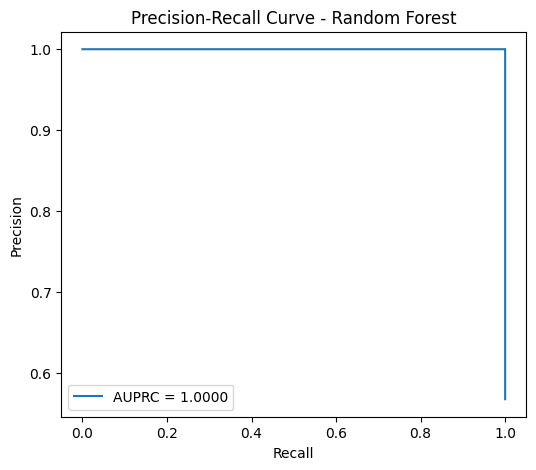

In [55]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Ensure y_prob_rf and y_test are correctly mapped for the PR curve
y_test_mapped = y_test.map({'BENIGN': 0, 'DDoS': 1})

precision, recall, thresholds_pr = precision_recall_curve(y_test_mapped, y_prob_rf)
auprc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AUPRC = {auprc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend()
plt.show()

### Precision-Recall Curve Interpretation

The Precision-Recall (PR) curve for the Random Forest model shows an **Area Under the Precision-Recall Curve (AUPRC) very close to 1.0**. This indicates exceptionally high precision across nearly all recall levels, especially in the high recall region.

**Implications for DDoS Detection:**
*   **High Performance**: The near-perfect AUPRC suggests that the model can effectively distinguish between DDoS and benign traffic. It means that when the model predicts a flow as DDoS, it is almost always correct (high precision), and it also identifies almost all actual DDoS attacks (high recall).
*   **Reliability**: In intrusion detection systems, minimizing false positives (predicting DDoS when it's benign) and false negatives (missing actual DDoS attacks) is crucial. A high AUPRC signifies that the model maintains strong performance in both aspects, even at various detection thresholds.
*   **Balanced Evaluation**: Unlike ROC-AUC, the PR curve focuses more on the positive class and is particularly informative for imbalanced datasets. The excellent AUPRC further reinforces the model's robustness, ensuring that its high performance is not an artifact of class imbalance (even though the imbalance here is moderate).

This strong performance on the PR curve, combined with the high ROC-AUC, further validates the Random Forest model's suitability for this DDoS detection task, indicating its capability to be highly precise while also capturing the majority of malicious traffic.

## Final Conclusion

In this project, a comprehensive machine learning pipeline was developed to classify network traffic flows as benign or DDoS attacks using flow-based features. The dataset was thoroughly explored, preprocessed, and analyzed to understand traffic behavior and feature distributions.

Feature selection and engineering were applied to reduce dimensionality while retaining highly informative attributes related to packet size, flow timing, and subflow behavior. Multiple classification models, including Logistic Regression, Random Forest, and Support Vector Machine, were evaluated to ensure robust performance assessment.

Among the tested models, ensemble and margin-based approaches achieved near-perfect performance, demonstrating strong separability between benign and DDoS traffic. Cross-validation and feature ablation experiments confirmed that the results were stable, generalizable within the dataset, and not dependent on a single feature or favorable data split.

Advanced evaluation metrics such as ROC–AUC and Precision–Recall analysis further validated the model’s effectiveness in distinguishing attack traffic while minimizing false positives. However, since the models rely on completed network flow statistics, the proposed approach is best suited for offline or near-real-time intrusion detection systems.

Overall, the results highlight the effectiveness of flow-based machine learning techniques for DDoS detection while acknowledging practical deployment constraints and the need for further validation in real-world network environments.
